Sobre el proyecto: https://github.com/HaloReach2552/Proyecto-Data-Science-Airbnb

In [1]:
import pandas as pd
import folium
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Only suppress deprecation warnings; keep others visible
warnings.filterwarnings('ignore')

In [2]:
url = "https://raw.githubusercontent.com/HaloReach2552/Proyecto-Data-Science-Airbnb/refs/heads/main/AB_US_2020.csv"

datos = pd.read_csv(url)
datos.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,38585,Charming Victorian home - twin beds + breakfast,165529,Evelyne,NaN,28804,35.65146,-82.62792,Private room,60,1,138,16/02/20,1.14,1,0,Asheville
1,80905,French Chic Loft,427027,Celeste,NaN,28801,35.59779,-82.55540,Entire home/apt,470,1,114,07/09/20,1.03,11,288,Asheville
2,108061,Walk to stores/parks/downtown. Fenced yard/Pet...,320564,Lisa,NaN,28801,35.60670,-82.55563,Entire home/apt,75,30,89,30/11/19,0.81,2,298,Asheville
3,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,NaN,28806,35.57864,-82.59578,Entire home/apt,90,1,267,22/09/20,2.39,5,0,Asheville
4,160594,Historic Grove Park,769252,Elizabeth,NaN,28801,35.61442,-82.54127,Private room,125,30,58,19/10/15,0.52,1,0,Asheville


In [3]:
#Tamaño de los datos
print(f"Hay {datos.shape[0]} filas y columnas hay {datos.shape[1]}.")

Hay 226030 filas y columnas hay 17.


In [4]:
#Eliminemos variables que no se va a trabajar
del datos["id"]
del datos["host_id"]


# Limpieza de Datos

In [5]:
datos.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,226030.000000,226030.000000,226030.000000,2.260300e+05,226030.000000,177428.00000,226030.000000,226030.000000
mean,35.662829,-103.220662,219.716529,4.525490e+02,34.506530,1.43145,16.698562,159.314856
std,6.849855,26.222091,570.353609,2.103376e+05,63.602914,1.68321,51.068966,140.179628
min,18.920990,-159.714900,0.000000,1.000000e+00,0.000000,0.01000,1.000000,0.000000
25%,32.761783,-118.598115,75.000000,1.000000e+00,1.000000,0.23000,1.000000,0.000000
50%,37.261125,-97.817200,121.000000,2.000000e+00,8.000000,0.81000,2.000000,140.000000
75%,40.724038,-76.919323,201.000000,7.000000e+00,39.000000,2.06000,6.000000,311.000000
max,47.734620,-70.995950,24999.000000,1.000000e+08,966.000000,44.06000,593.000000,365.000000


In [6]:
#En el codigo anterior vemos que el valor minimo de price es 0 y eso no puede 

datos = datos[datos["price"]> 9]
datos.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,225959.000000,225959.000000,225959.000000,2.259590e+05,225959.000000,177403.000000,225959.000000,225959.000000
mean,35.662320,-103.223011,219.785439,4.526897e+02,34.510703,1.431389,16.702017,159.351183
std,6.850261,26.222926,570.429958,2.103706e+05,63.606123,1.683146,51.076408,140.175653
min,18.920990,-159.714900,10.000000,1.000000e+00,0.000000,0.010000,1.000000,0.000000
25%,32.761760,-118.598250,75.000000,1.000000e+00,1.000000,0.230000,1.000000,0.000000
50%,37.260140,-97.817700,122.000000,2.000000e+00,8.000000,0.810000,2.000000,140.000000
75%,40.724025,-76.922640,201.000000,7.000000e+00,39.000000,2.060000,6.000000,311.000000
max,47.734620,-70.995950,24999.000000,1.000000e+08,966.000000,44.060000,593.000000,365.000000


In [7]:
# Aqui estamos viendo la cantidad de datos nulos de todas las variables y expresadas en %
datos_nulos=pd.DataFrame({
    'Nulos': datos.isnull().sum(),
    'Porcentaje (%)': (datos.isnull().sum() / len(datos) * 100).round(2)
})

datos_nulos

,Nulos,Porcentaje (%)
name,28,0.01
host_name,33,0.01
neighbourhood_group,115813,51.25
neighbourhood,0,0.00
latitude,0,0.00
longitude,0,0.00
room_type,0,0.00
price,0,0.00
minimum_nights,0,0.00
number_of_reviews,0,0.00


In [8]:
# Reemplazar valores nulos por "Unknown"
datos["name"] = datos["name"].fillna("Unknown")
datos["host_name"] = datos["host_name"].fillna("Unknown")

# Si un alojamiento no tiene reseñas, la tasa de reseñas por mes es 0.
datos["reviews_per_month"] = datos["reviews_per_month"].fillna(0)

In [9]:
# Al final esta es la BBDD con la cual se trabajara el EDA
datos.head(3)

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,Charming Victorian home - twin beds + breakfast,Evelyne,NaN,28804,35.65146,-82.62792,Private room,60,1,138,16/02/20,1.14,1,0,Asheville
1,French Chic Loft,Celeste,NaN,28801,35.59779,-82.55540,Entire home/apt,470,1,114,07/09/20,1.03,11,288,Asheville
2,Walk to stores/parks/downtown. Fenced yard/Pet...,Lisa,NaN,28801,35.60670,-82.55563,Entire home/apt,75,30,89,30/11/19,0.81,2,298,Asheville


# Analisis Exploratorio de los datos EDA

In [10]:
datos["name"] = (
    datos["name"]
    .str.lower()
    .str.strip()
)

In [11]:
#El Top 10 de los 
datos["name"].value_counts().sort_values(ascending=False).head(10)

name
home away from home                                172
private room                                        66
a place of your own | 2br in las vegas              62
cozy place to call home | 1br in los angeles        48
stay in a place of your own | 1br in washington     43
home sweet home                                     40
union square convention hotel                       40
a place of your own | 1br in las vegas              36
well-equipped apartment home | 1br in boston        36
cozy room                                           36
Name: count, dtype: int64

In [12]:
#El Top10 de las ciudades en las que Airbnb esta ofreciendo el servicio de hospedaje
datos["city"].value_counts().sort_values(ascending=False).head(10)

city
New York City        45730
Los Angeles          31526
Hawaii               22433
San Diego            12403
Broward County       10855
Austin               10430
Clark County          8408
Washington D.C.       7349
San Clara Country     7091
San Francisco         7053
Name: count, dtype: int64

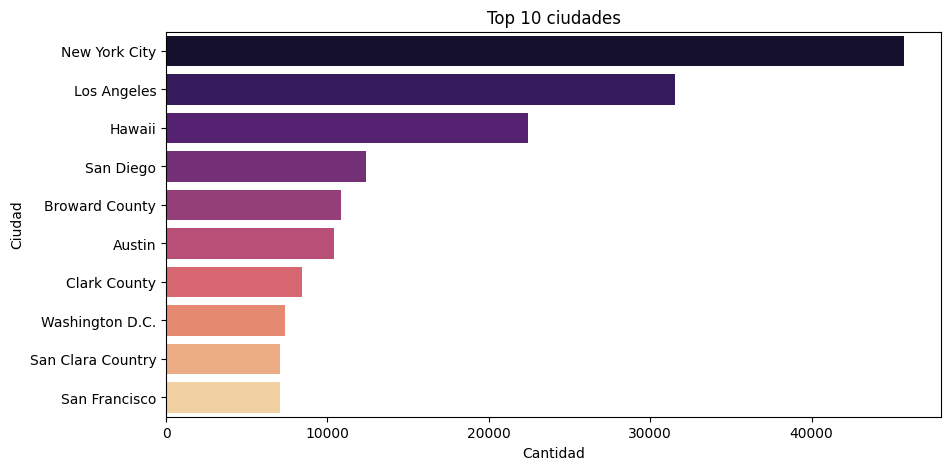

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=datos,
    y="city",
    order=datos["city"].value_counts().head(10).index,
    palette="magma"
)

plt.title("Top 10 ciudades")
plt.xlabel("Cantidad")
plt.ylabel("Ciudad")
plt.show()

In [14]:
datos["room_type"].value_counts()

room_type
Entire home/apt    154162
Private room        65870
Shared room          4026
Hotel room           1901
Name: count, dtype: int64

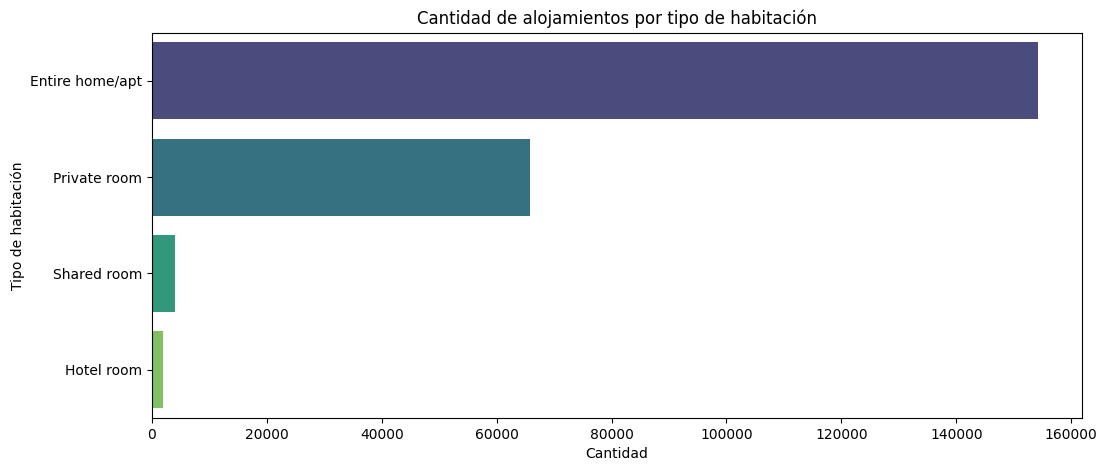

In [41]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=datos,
    y="room_type",
    order=datos["room_type"].value_counts().index,
    palette="viridis"
)

plt.title("Cantidad de alojamientos por tipo de habitación")
plt.xlabel("Cantidad")
plt.ylabel("Tipo de habitación")

plt.show()

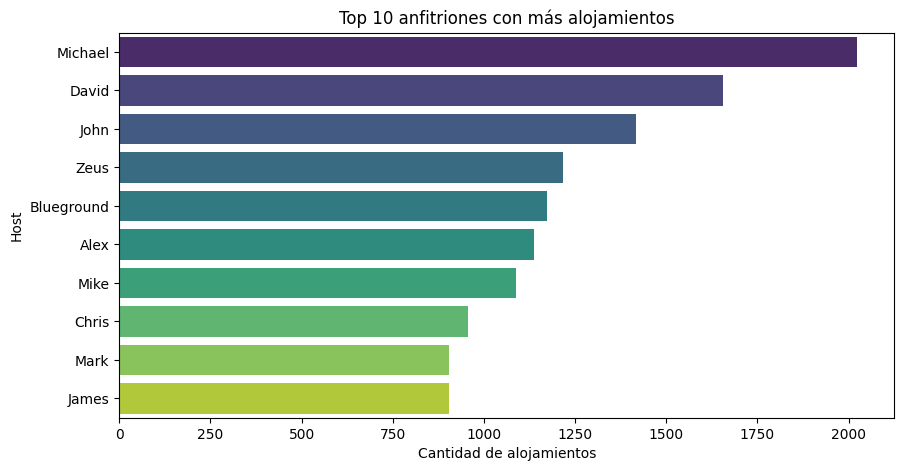

In [16]:
top_hosts = datos["host_name"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_hosts.values,
    y=top_hosts.index,
    palette="viridis"
)

plt.title("Top 10 anfitriones con más alojamientos")
plt.xlabel("Cantidad de alojamientos")
plt.ylabel("Host")

plt.show()

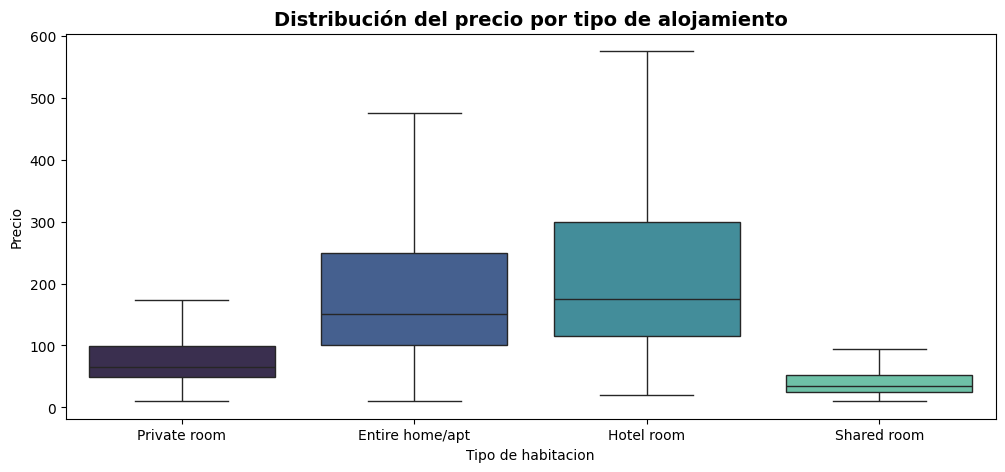

In [40]:
plt.figure(figsize=(12,5))
sns.boxplot(data=datos, x='room_type', y='price', showfliers=False, palette= "mako")
plt.title('Distribución del precio por tipo de alojamiento', fontsize=14, fontweight='bold')
plt.xlabel("Tipo de habitacion")
plt.ylabel("Precio")
plt.show()

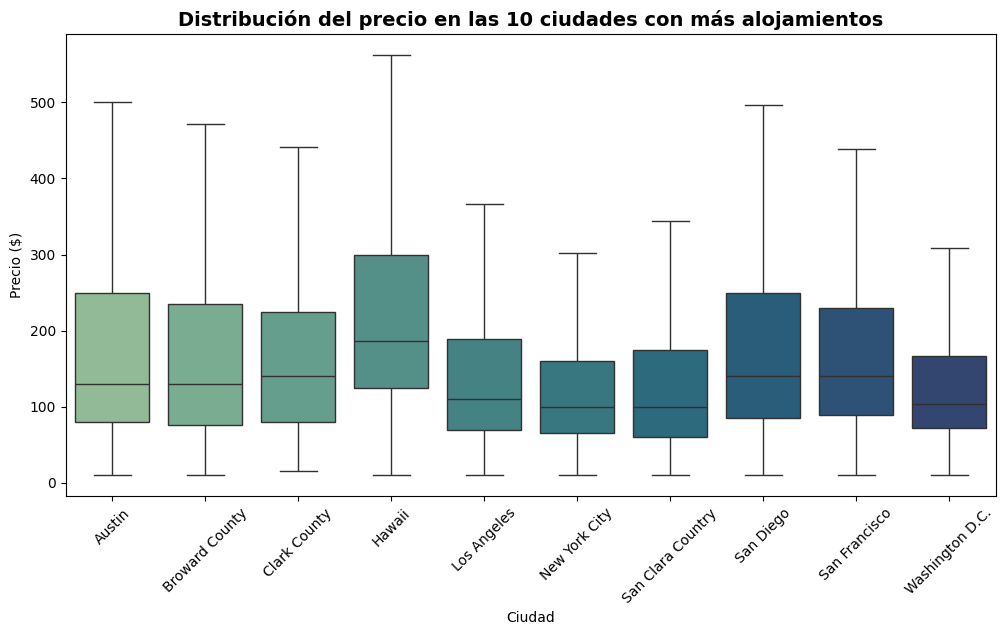

In [ ]:
# 10 ciudades con más alojamientos
top_ciudades = datos['city'].value_counts().head(10).index

df_top = datos[datos['city'].isin(top_ciudades)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='city', y='price', showfliers=False, palette= "crest")

plt.title('Distribución del precio en las 10 ciudades con más alojamientos',
          fontsize=14, fontweight='bold')
plt.xlabel('Ciudad')
plt.ylabel('Precio ($)')
plt.xticks(rotation=45)

plt.show()

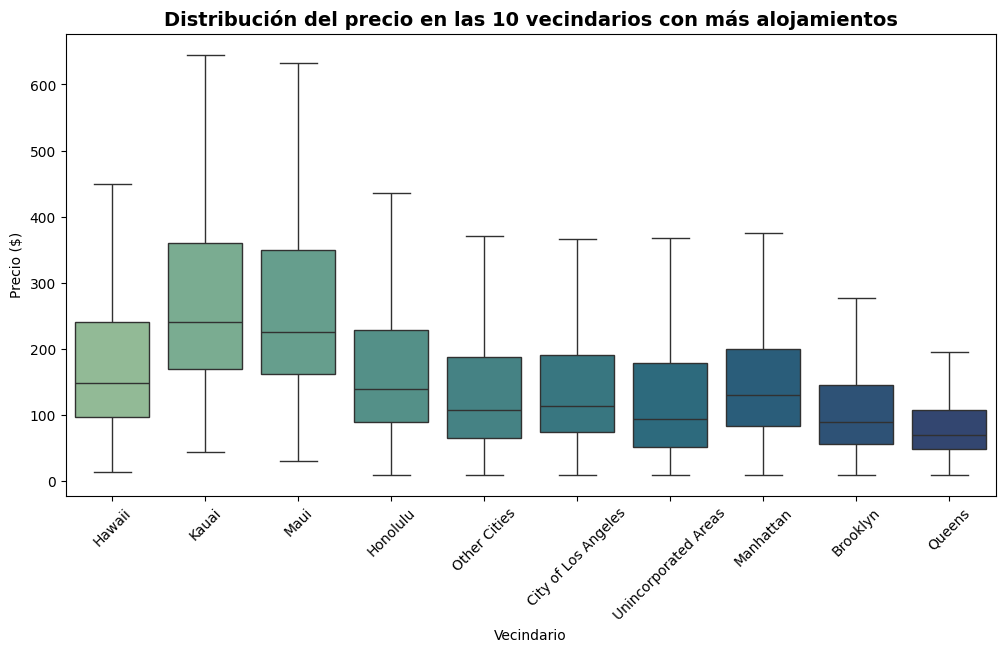

In [ ]:
# 10 distritos con más alojamientos
top_ciudades = datos['neighbourhood_group'].value_counts().head(10).index

df_top = datos[datos['neighbourhood_group'].isin(top_ciudades)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='neighbourhood_group', y='price', showfliers=False, palette= "crest")

plt.title('Distribución del precio en las 10 vecindarios con más alojamientos',
          fontsize=14, fontweight='bold')
plt.xlabel('Vecindario')
plt.ylabel('Precio ($)')
plt.xticks(rotation=45)

plt.show()

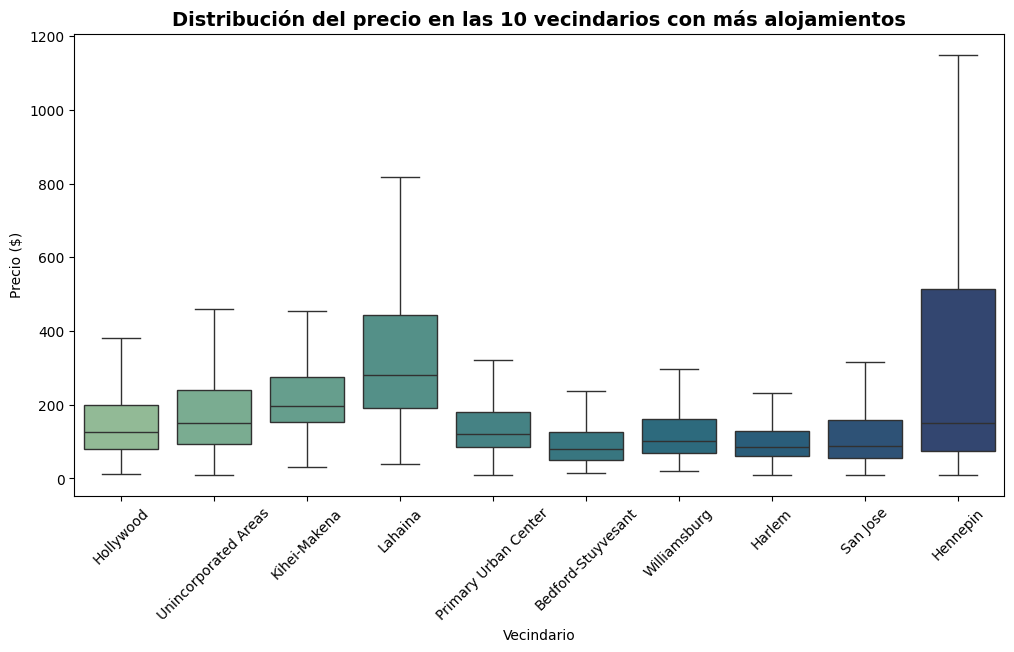

In [ ]:
# 10 vecindarios con más alojamientos
top_ciudades = datos['neighbourhood'].value_counts().head(10).index

df_top = datos[datos['neighbourhood'].isin(top_ciudades)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='neighbourhood', y='price', showfliers=False, palette= "crest")

plt.title('Distribución del precio en las 10 vecindarios con más alojamientos',
          fontsize=14, fontweight='bold')
plt.xlabel('Vecindario')
plt.ylabel('Precio ($)')
plt.xticks(rotation=45)

plt.show()

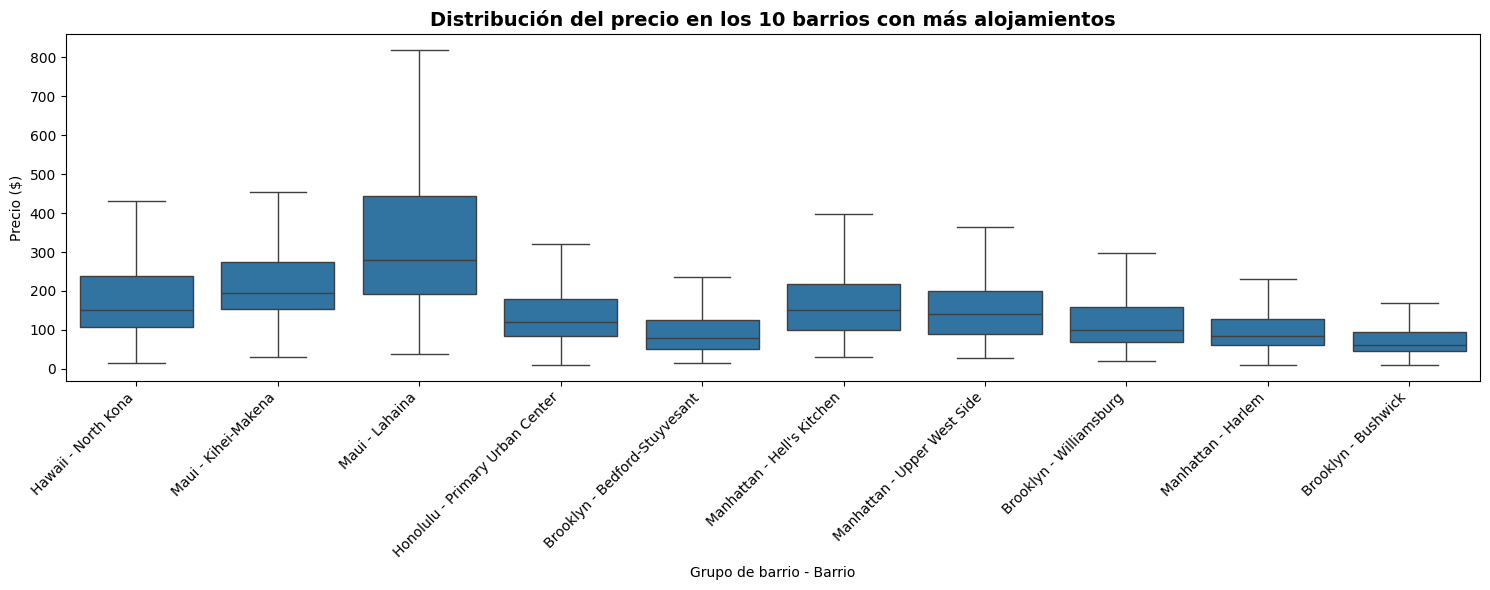

In [53]:
datos['zona_barrio'] = (
    datos['neighbourhood_group'] + ' - ' + datos['neighbourhood']
)

top10 = datos['zona_barrio'].value_counts().head(10).index
df_top10 = datos[datos['zona_barrio'].isin(top10)]

plt.figure(figsize=(15,6))
sns.boxplot(
    data=df_top10,
    x='zona_barrio',
    y='price',
    showfliers=False
)

plt.title('Distribución del precio en los 10 barrios con más alojamientos',
          fontsize=14, fontweight='bold')
plt.xlabel('Grupo de barrio - Barrio')
plt.ylabel('Precio ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()